# Quantization Aware Training + Knowledge Distillation 
## PyTorch -> TfLite

In [1]:
import os
import torch

from src.utils import load_data, process_callbacks
from src.quantization.converters.to_tflite import convert_pytorch_model_to_tflite
from src.train.knowledge_distillation import train_qat_kd
from src.utils.logging_setup import configure_logging

 You need to install pymongo>=3.9.0 in order to use MongoOutput 
2025-04-23 18:02:30.085599: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-23 18:02:30.094289: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745445750.103510   55897 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745445750.106591   55897 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745445750.114592   55897 computation_placer.cc:177] computation p

In [2]:
# Specify random seed for repeatable results
_ = torch.manual_seed(191009)

configure_logging(True)

### Hyperparameters

[INFO 2025-04-23 18:02:31,458 preprocessing.py:17] Train dataset size: 29322
[INFO 2025-04-23 18:02:31,459 preprocessing.py:26] Class distribution for train dataset:
[INFO 2025-04-23 18:02:31,460 preprocessing.py:28]   Class 'Actinic keratoses': 693 samples
[INFO 2025-04-23 18:02:31,460 preprocessing.py:28]   Class 'Basal cell carcinoma': 2658 samples
[INFO 2025-04-23 18:02:31,460 preprocessing.py:28]   Class 'Benign keratosis-like lesions': 2099 samples
[INFO 2025-04-23 18:02:31,460 preprocessing.py:28]   Class 'Chickenpox': 900 samples
[INFO 2025-04-23 18:02:31,460 preprocessing.py:28]   Class 'Cowpox': 792 samples
[INFO 2025-04-23 18:02:31,460 preprocessing.py:28]   Class 'Dermatofibroma': 191 samples
[INFO 2025-04-23 18:02:31,461 preprocessing.py:28]   Class 'HFMD': 1932 samples
[INFO 2025-04-23 18:02:31,461 preprocessing.py:28]   Class 'Healthy': 1368 samples
[INFO 2025-04-23 18:02:31,461 preprocessing.py:28]   Class 'Measles': 660 samples
[INFO 2025-04-23 18:02:31,461 preprocessi

Model prepared using Export Mode QAT.


Train Epoch 1/1: 100%|██████████| 917/917 [03:11<00:00,  4.80it/s, loss=0.8438]
[INFO 2025-04-23 18:05:46,481 knowledge_distillation.py:109] Train Loss: 0.8438
[INFO 2025-04-23 18:05:46,481 knowledge_distillation.py:110] Train Metrics: accuracy: 0.6956, recall: 0.5013, precision: 0.5948, f1-score: 0.5244, auc-score: 0.9414
[INFO 2025-04-23 18:05:46,484 eval.py:150] Starting inference...
Inference Progress: 100%|██████████| 115/115 [00:19<00:00,  6.05it/s]
[INFO 2025-04-23 18:06:05,757 eval.py:178] Inference complete.
[INFO 2025-04-23 18:06:05,785 knowledge_distillation.py:203] Val Loss: 0.7157
[INFO 2025-04-23 18:06:05,785 knowledge_distillation.py:204] Val Metrics: accuracy: 0.7426, recall: 0.6339, precision: 0.6663, f1-score: 0.6191, auc-score: 0.9669
[INFO 2025-04-23 18:06:05,923 knowledge_distillation.py:333] Training complete in 3m 31s
[INFO 2025-04-23 18:06:06,010 knowledge_distillation.py:343] Best model weights loaded from: models/SkinCancer/Quantized/mobilenet_v2_qat_kd.pth
[I

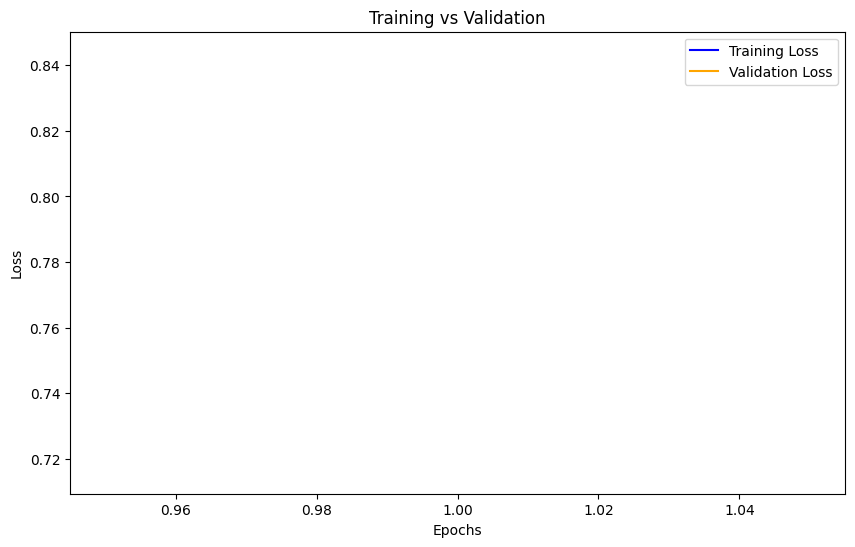

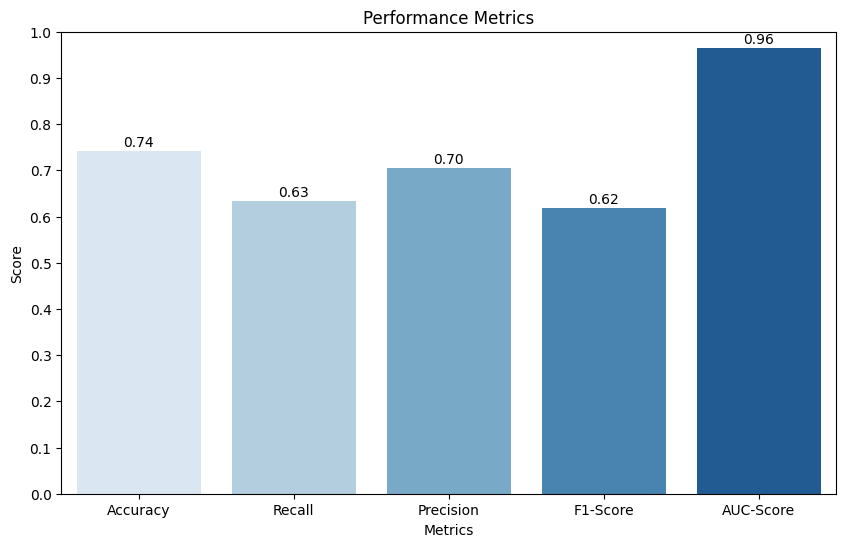

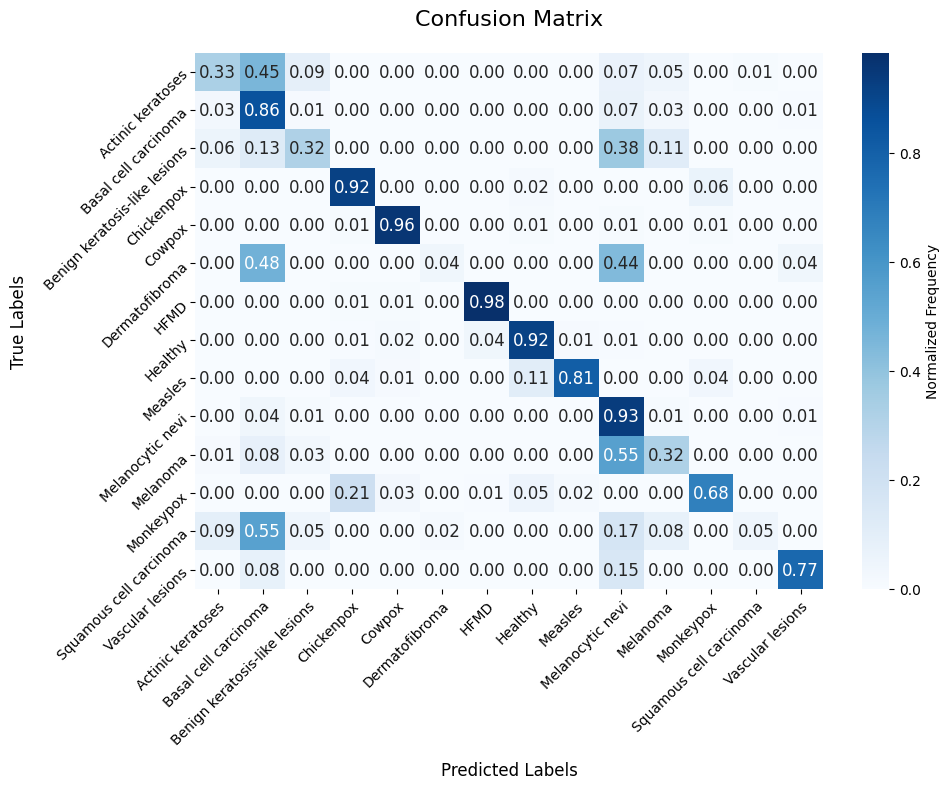

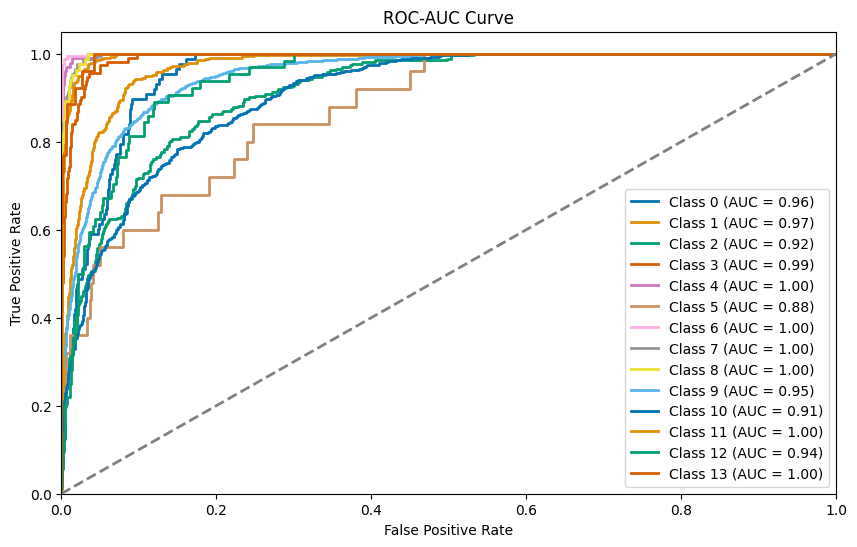

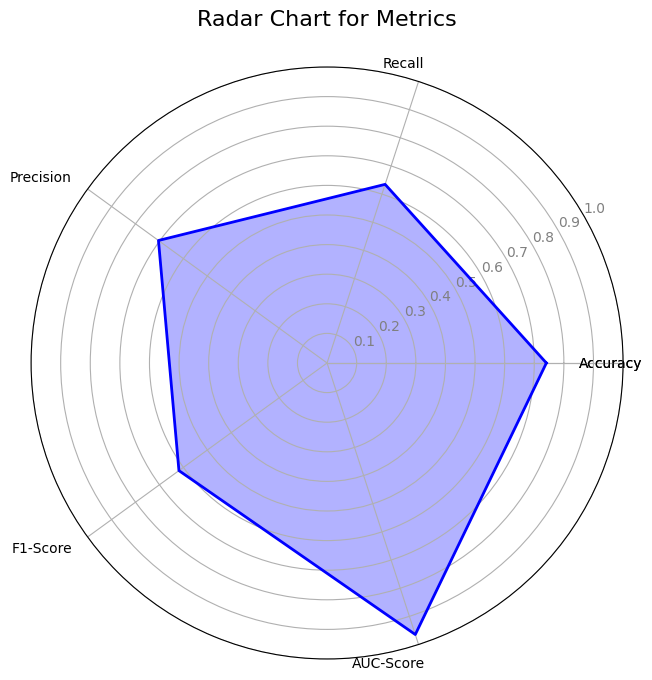

In [3]:
dataset = "SkinCancer"
batch_size = 32
learning_rate = 0.001
epochs = 1
save_dir = f"models/{dataset}/Quantized"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher_model = "mobilenet_v2"
student_model = "mobilenet_v2"
args = {"callbacks": ["ModelCheckpoint", "EarlyStopping", "ReduceLROnPlateau"], 
        "save_dir": save_dir, 
        "model_name": student_model,
        "save_name": "qat_kd"}
CALLBACKS = list(process_callbacks(args).values())

os.makedirs(save_dir, exist_ok=True)

dataloaders = load_data(dataset=dataset, batch_size=batch_size)

teacher_model_weights = 'models/SkinCancer/mobilenet_v2_best_model.pth'  # Update with your saved model weights

criterion = "cross_entropy"
optimizer = "adam"

teacher, quantized_student = train_qat_kd(
                                        teacher_name=teacher_model, 
                                        student_name=student_model,
                                        data_loaders=dataloaders,
                                        save_dir=save_dir,
                                        learning_rate=learning_rate,
                                        epochs=epochs,
                                        criterion = criterion,
                                        optimizer = optimizer,
                                        callbacks=CALLBACKS,
                                        quant_mode="export",
                                        teacher_model_weights=teacher_model_weights,
                                        device=device,
                                )


### 2. Export to TfLite

In [4]:
example_inputs = next(iter(dataloaders['train']))[0]
tflite_path = os.path.join(save_dir, f"{student_model}_qat_kd.tflite")
convert_pytorch_model_to_tflite(quantized_student, (example_inputs,), tflite_path)

[INFO 2025-04-23 18:08:21,922 to_tflite.py:24] Converting PyTorch model to TensorFlow Lite format.
[WARNING 2025-04-23 18:08:21,922 conversion.py:77] Your model is converted in training mode. Please set the module in evaluation mode with `module.eval()` for better on-device performance and compatibility.
[INFO 2025-04-23 18:08:30,990 _jax_lowerings.py:32] Use JAX lowering: aten.permute
[INFO 2025-04-23 18:08:30,994 _jax_lowerings.py:32] Use JAX lowering: aten.clone.default
[INFO 2025-04-23 18:08:31,003 _jax_lowerings.py:32] Use JAX lowering: aten.add.Tensor
[INFO 2025-04-23 18:08:31,007 _jax_lowerings.py:32] Use JAX lowering: aten.hardtanh
[INFO 2025-04-23 18:08:31,571 _jax_lowerings.py:32] Use JAX lowering: aten.mean
[INFO 2025-04-23 18:08:31,576 _jax_lowerings.py:32] Use JAX lowering: aten.view
[INFO 2025-04-23 18:08:31,581 _jax_lowerings.py:32] Use JAX lowering: aten.mm
[INFO 2025-04-23 18:08:31,584 _jax_lowerings.py:32] Use JAX lowering: aten.mul.Tensor
I0000 00:00:1745446111.65526

ConverterError: /home/jacob-delgado/anaconda3/envs/ECG/lib/python3.12/site-packages/torchvision/models/mobilenetv2.py:170:0: error: 'stablehlo.uniform_dequantize' op operand #0 must be tensor of 2/4/8/16/32-bit uniform quantized signed integer or 2/4/8/16/32-bit uniform quantized unsigned integer or 2/4/8/16/32-bit uniform quantized per axis signed integer or 2/4/8/16/32-bit uniform quantized per axis unsigned integer values, but got 'tensor<14x1280xi8>'


### 3. Model Sizes

In [6]:
print("qat:", os.path.getsize("models/SkinCancer/Quantized/quantized_state.pth") / 1e6)
print("tflite:", os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2_qat_kd.tflite") / 1e6)

qat: 9.292454
tflite: 9.026928
